In [37]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window
from pyspark.sql.types import *
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
spark = SparkSession.builder.appName("Retail Black Friday Sales Analytics").getOrCreate()

DATA EXTRACTION--

In [3]:
df= spark.read.format("csv").option("inferSchema","true").option("header","true").option("path","retail_black_friday_sales_100k.csv").load()

DATA PROFILLING--

In [4]:
df.count()

100000

In [5]:
df.printSchema()

root
 |-- transaction_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- city: string (nullable = true)
 |-- customer_segment: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- original_price: double (nullable = true)
 |-- discount_pct: integer (nullable = true)
 |-- final_price: double (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- purchase_amount: double (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- purchase_date: date (nullable = true)
 |-- purchase_hour: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- is_black_friday: integer (nullable = true)



In [6]:
print("Duplicate Records: ", df.count() - df.distinct().count()) 

Duplicate Records:  0


In [7]:
null_counts = df.select([ count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show()

+--------------+-----------+---------+------+----+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|transaction_id|customer_id|age_group|gender|city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|
+--------------+-----------+---------+------+----+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|             0|          0|        0|     0|   0|               0|         0|               0|             0|           0|          0|       0|              0|             0|            0|            0|         0|              0|
+--------------+-----------+---------+------+----+----------------+---------

In [8]:
df.show(10)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+
|      T0000001|    C007297|    26-35|  Male|San Francisco|           Loyal|     P2713|        Footwear|        153.73|          35|      99.92|       1|          99.92|   Credit Card|   2025-12-01|            0|         0|              0|
|      T0000002|    C001640|      56+| O

TRANSFORM--

In [9]:
df.dropDuplicates()


DataFrame[transaction_id: string, customer_id: string, age_group: string, gender: string, city: string, customer_segment: string, product_id: string, product_category: string, original_price: double, discount_pct: int, final_price: double, quantity: int, purchase_amount: double, payment_method: string, purchase_date: date, purchase_hour: int, is_weekend: int, is_black_friday: int]

In [10]:
df= df.withColumn("purchase", col("purchase_amount").cast("int"))

In [11]:
df = df.withColumn("Discount_Percentage", col("discount_pct").cast("double"))

In [12]:
df.show(5)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|purchase|Discount_Percentage|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+
|      T0000001|    C007297|    26-35|  Male|San Francisco|           Loyal|     P2713|        Footwear|        153.73|          35|      99.92|       1|          99.92|   Credit Card|   2025-1

In [13]:
df = df.withColumn("Revenue_Per_Customer", round(col("original_price") - col("final_price"), 2))

In [14]:
df = df.withColumn("High_Value_Order_Flag", when(col("purchase_amount") > 100,1).otherwise(0))

In [15]:
df = df.withColumn("Weekend_Sale_Flag" , when(col("is_weekend") == 1, 1).otherwise(0))

In [16]:
df = df.withColumn("Product_Category_Count" , count("product_category").over(
    Window.partitionBy("customer_id")
))

Advanced Transformations--

In [17]:
df.groupBy("product_category").agg(sum("purchase").alias("Total_purchase_amount")).orderBy(col("Total_purchase_amount").desc()).show()

+----------------+---------------------+
|product_category|Total_purchase_amount|
+----------------+---------------------+
|     Electronics|             14118520|
|  Home & Kitchen|              6456256|
|          Sports|              3298662|
|     Accessories|              2749540|
|        Footwear|              2008343|
|        Clothing|              1683604|
|            Toys|              1664230|
|          Beauty|              1369814|
|       Groceries|              1071090|
|           Books|               656320|
+----------------+---------------------+



In [18]:
df.groupBy("customer_id").agg(
    count("purchase").alias("Total_Purchase")
).orderBy(col("Total_Purchase").desc()).show(15)

+-----------+--------------+
|customer_id|Total_Purchase|
+-----------+--------------+
|    C016694|            12|
|    C019611|            11|
|    C005664|            11|
|    C004476|            10|
|    C032741|            10|
|    C013732|            10|
|    C013580|            10|
|    C007666|            10|
|    C002424|            10|
|    C033266|            10|
|    C025205|            10|
|    C009513|            10|
|    C028102|            10|
|    C010507|            10|
|    C029522|            10|
+-----------+--------------+
only showing top 15 rows



In [19]:
df.groupBy("city").agg(
    sum("purchase").alias("Total_sales")
).orderBy(col("Total_sales").desc()).show()

+-------------+-----------+
|         city|Total_sales|
+-------------+-----------+
|      Atlanta|    3613414|
|        Miami|    3561872|
|       Dallas|    3543061|
|     New York|    3541513|
|      Phoenix|    3521107|
|      Chicago|    3507430|
|      Houston|    3470030|
|      Seattle|    3451838|
|San Francisco|    3440449|
|  Los Angeles|    3425665|
+-------------+-----------+



In [43]:
df.withColumn("Sales_Rank" , dense_rank().over(
    Window.partitionBy("product_category").orderBy(col("purchase").desc())
)).show(10)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--------------------+---------------------+-----------------+----------------------+--------------------------+----------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|purchase|Discount_Percentage|Revenue_Per_Customer|High_Value_Order_Flag|Weekend_Sale_Flag|Product_Category_Count|comparing_discount_percent|Sales_Rank|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+------

In [21]:
df.groupBy("purchase_hour").agg(sum("purchase").alias("Total_Sales")).orderBy(col("Total_sales").desc()).show()

+-------------+-----------+
|purchase_hour|Total_Sales|
+-------------+-----------+
|            5|    1529970|
|           21|    1521872|
|           12|    1517789|
|           10|    1513592|
|           22|    1512451|
|           17|    1504953|
|            2|    1487289|
|            8|    1479447|
|           20|    1469131|
|            6|    1467557|
|            7|    1458049|
|            1|    1457000|
|           19|    1454458|
|           14|    1446854|
|            3|    1444749|
|           18|    1441876|
|           15|    1437316|
|            9|    1434520|
|           23|    1431008|
|            0|    1424444|
+-------------+-----------+
only showing top 20 rows



Use Case 2 — Customer Purchase Intelligence--

Required ETL Tasks:

In [22]:
# Analyze customer purchase frequency
customer_puchase_frequency= df.groupBy("customer_id").agg(count("product_id").alias("Purchase_Frequency")).orderBy(col("Purchase_Frequency").desc()).show(20)
    

+-----------+------------------+
|customer_id|Purchase_Frequency|
+-----------+------------------+
|    C016694|                12|
|    C019611|                11|
|    C005664|                11|
|    C029617|                10|
|    C013580|                10|
|    C002424|                10|
|    C018939|                10|
|    C013732|                10|
|    C004476|                10|
|    C032741|                10|
|    C009513|                10|
|    C003925|                10|
|    C010507|                10|
|    C007666|                10|
|    C025205|                10|
|    C028102|                10|
|    C029522|                10|
|    C026627|                10|
|    C021437|                10|
|    C033266|                10|
+-----------+------------------+
only showing top 20 rows



In [23]:
average_purchase_per_customer = df.groupBy("customer_id").agg(avg("purchase").alias("average_purchase")).orderBy(col("average_purchase").desc()).show(20)

+-----------+----------------+
|customer_id|average_purchase|
+-----------+----------------+
|    C001720|          8937.0|
|    C034698|          8470.0|
|    C018517|          8150.0|
|    C024043|          7558.0|
|    C017134|          6423.0|
|    C008641|          6297.0|
|    C005090|          6288.0|
|    C015958|          5792.0|
|    C021735|          5677.0|
|    C022668|          5582.0|
|    C025785|          5120.0|
|    C029437|          5044.0|
|    C012521|          4742.0|
|    C025121|          4679.0|
|    C008962|          4537.0|
|    C010189|          4480.0|
|    C002469|          4475.0|
|    C005189|          4470.0|
|    C026206|          4440.0|
|    C011328|          4407.0|
+-----------+----------------+
only showing top 20 rows



In [51]:
df = df.withColumn("comparing_discount_percent", when(col("discount_pct") > 20,1 ).otherwise(0))

In [46]:
df.show(10)

+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+--------+-------------------+--------------------+---------------------+-----------------+----------------------+--------------------------+
|transaction_id|customer_id|age_group|gender|         city|customer_segment|product_id|product_category|original_price|discount_pct|final_price|quantity|purchase_amount|payment_method|purchase_date|purchase_hour|is_weekend|is_black_friday|purchase|Discount_Percentage|Revenue_Per_Customer|High_Value_Order_Flag|Weekend_Sale_Flag|Product_Category_Count|comparing_discount_percent|
+--------------+-----------+---------+------+-------------+----------------+----------+----------------+--------------+------------+-----------+--------+---------------+--------------+-------------+-------------+----------+---------------+-

In [25]:
# Identify repeat customers
repeat_customers = df.groupBy("customer_id").agg(count("customer_id").alias("cust_id")).filter(col("cust_id") > 1).count()
print(repeat_customers)

27234


Visualizations Required--

In [26]:
# Visual 1 — Top Customers by Revenue
customer_revenue = df.groupBy("customer_id").agg(sum("purchase").alias("Total_Revenue")).orderBy(col("Total_Revenue").desc()).limit(10)


<Axes: xlabel='Total_Revenue', ylabel='customer_id'>

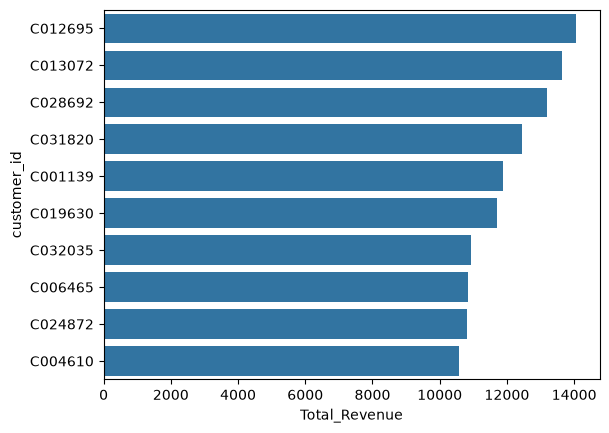

In [27]:
sns.barplot(data=customer_revenue.toPandas(),x="Total_Revenue",y="customer_id")

<Axes: xlabel='comparing_discount_percent', ylabel='Count'>

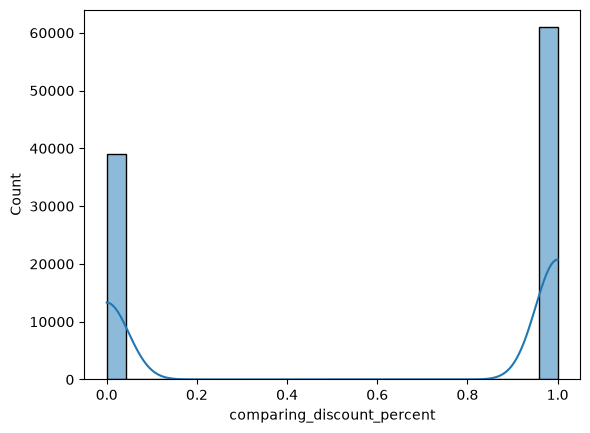

In [ ]:
# Visual 2 — Discount vs Sales Distribution
distribution = df.select("comparing_discount_percent").+.
sns.histplot(data=distribution.toPandas(), x="comparing_discount_percent",kde=True)


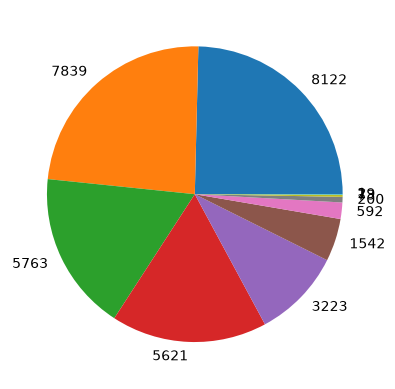

In [42]:
# Visual 3 — Customer Purchase Frequency Analysis
customer_purchase_frequency= df.groupBy("customer_id").agg(count("product_id").alias("Purchase_Frequency")).orderBy(col("Purchase_Frequency").desc())
plt.pie(customer_purchase_frequency.toPandas()["Purchase_Frequency"].value_counts(), labels=customer_purchase_frequency.toPandas()["Purchase_Frequency"].value_counts())

    